In [1]:
%load_ext autoreload
%autoreload 2

# 511 keV Galactic Imaging

**Objective**

Construct and analyze the extended 511 keV emission image in Galactic coordinates using:

- The binned 511 keV data.
- The precomputed extended-source response.
- The spacecraft attitude history.

This notebook focuses on the spatial distribution of the Galactic disk and bulge.

***
## Setup

In [2]:
# Setting the root path for the imports
from pathlib import Path
import sys

working_dir=Path.cwd()
repo_root = (
    working_dir.parent 
    if working_dir.name =='notebooks' 
    else working_dir
    )
if str(repo_root) not in sys.path: sys.path.insert(0,str(repo_root))

### Imports

In [49]:

import numpy as np
import cosipy as cp
import matplotlib.pyplot as plt


# from cosipy.response import FullDetectorResponse


# from scoords import SpacecraftFrame

from astropy.io import fits
# import astropy.units as u
# from astropy.coordinates import SkyCoord
# from astromodels import Parameter, Powerlaw

import h5py


%matplotlib inline

### Paths to input products

In [4]:
# Input products: Adding all paths to be used for this analysis. See `workflor/src/path_to_files.py`
from src import path_to_files as paths

In [5]:
# Validate input products
print(paths.data_ext_response511_path)
print(paths.data_ori_path)
print(paths.data_dir_out)

/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/extended_source_response_511_merged.h5
/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
/Users/maura/Documents/COSI/data-challenge-4/workflow/data/outputs


***
## Load 511 keV data

In [6]:
yaml_conf = paths.config_511_path

# Load spacecraft orientation hystory
orientation = cp.SpacecraftHistory.open(paths.data_ori_path)

### Inspect extended-source response

In [7]:
# Load detector response
with h5py.File(paths.data_ext_response511_path, 'r') as response_file:
    extended_response = response_file["hist/contents"][:]
    response_axes = [
        response_file[f"hist/axes/{i}"][:]
        for i in range(5)
    ]

    print(extended_response.shape)
    for i, axis in enumerate(response_axes):
        print(f"Axis {i}: {axis.shape}, first values: {axis[:15]}")

    for i in range(5):
        axis = response_file[f"hist/axes/{i}"]
        print(f"Axis {i}:", dict(axis.attrs))

    print("Contents:", dict(response_file["hist/contents"].attrs))

(3072, 1, 1, 60, 3072)
Axis 0: (3073,), first values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Axis 1: (2,), first values: [509. 513.]
Axis 2: (2,), first values: [509. 513.]
Axis 3: (61,), first values: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27. 30. 33. 36. 39. 42.]
Axis 4: (3073,), first values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Axis 0: {'__class__': array(['histpy.healpix_axis', 'HealpixAxis'], dtype=object), 'coordsys': 'galactic', 'label': 'NuLambda', 'nside': np.int64(16), 'scheme': 'RING'}
Axis 1: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Ei', 'scale': 'log', 'unit': 'keV'}
Axis 2: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Em', 'scale': 'log', 'unit': 'keV'}
Axis 3: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Phi', 'scale': 'linear', 'unit': 'deg'}
Axis 4: {'__class__': array(['histpy.healpix_axis', 'HealpixAxis'], dtype=object), 'coordsys': 'galactic', 'label': 'PsiChi', 'nside': 

### Single week

In [8]:
# Single dataset binned. Load one binned dataset as an initial validation before
# processing all weeks.
binned511_w1 = paths.data_dir_out / "dc4_week_1_511_binned.hdf5"

analysis511_week1 = cp.BinnedData(yaml_conf)
analysis511_week1.load_binned_data_from_hdf5(binned_data= binned511_w1)
analysis511_week1.get_binning_info()

In [9]:
print(analysis511_week1.binned_data.shape)
print(len(analysis511_week1.time_bin_centers))

(2217, 1, 60, 3072)
2217


In [10]:
# Convert the sparse observed histogram to a dense array
data_contents = np.asarray(
    analysis511_week1.binned_data.contents.todense()
)

# Sum over time and incident-energy axes
observed_counts = data_contents.sum(axis=(0, 1))


In [11]:
print(observed_counts.shape)
print(observed_counts.sum())

(60, 3072)
119213.0


#### Validate data–response and temporal compatibility

In [12]:
# Observed data: (time, Em, Phi, PsiChi)
print("Data shape:", analysis511_week1.binned_data.shape)

# Extended response: (NuLambda, Ei, Em, Phi, PsiChi)
print("Response shape:", extended_response.shape)

assert analysis511_week1.binned_data.shape[1] == 1
assert analysis511_week1.binned_data.shape[2] == extended_response.shape[3]
assert analysis511_week1.binned_data.shape[3] == extended_response.shape[4]

print("Data and response axes are compatible.")
#print("Total observed counts:", analysis511_week1.binned_data.sum())
print("Response range:", extended_response.min(), extended_response.max())

Data shape: (2217, 1, 60, 3072)
Response shape: (3072, 1, 1, 60, 3072)
Data and response axes are compatible.
Response range: 0.0 13949.2242181167


In [13]:
print("Data time bins:", analysis511_week1.binned_data.shape[0])
print("History intervals:", orientation.nintervals)
print("History points:", orientation.npoints)

print("Orientation time range:")
print(orientation.tstart, orientation.tstop)

print("Orientation intervals:")
print(orientation.intervals_tstart[:3])
print(orientation.intervals_tstop[:3])

print("Orientation livetime shape:", np.shape(orientation.livetime))
print("Orientation attitude shape:", np.shape(orientation.attitude))

Data time bins: 2217
History intervals: 531997
History points: 531998
Orientation time range:
1835487300.0 1843467255.0
Orientation intervals:
[1.83548730e+09 1.83548732e+09 1.83548733e+09]
[1.83548732e+09 1.83548733e+09 1.83548734e+09]
Orientation livetime shape: (531997,)
Orientation attitude shape: (531998,)


In [14]:
print("Data time range:", analysis511_week1.tmin, analysis511_week1.tmax)
print("Data bins:", analysis511_week1.time_bins)
print("Data bin edges:", analysis511_week1.time_bin_edges[:3])
print(analysis511_week1.time_bin_edges[-3:])

print("Orientation range:", orientation.tstart, orientation.tstop)


data_tmin = float(analysis511_week1.tmin)
data_tmax = float(analysis511_week1.tmax)

orientation_tstart = orientation.tstart.unix
orientation_tstop = orientation.tstop.unix

assert data_tmin >= orientation_tstart
assert data_tmax <= orientation_tstop

print("Data:", data_tmin, data_tmax)
print("Orientation:", orientation_tstart, orientation_tstop)


print("Temporal coverage is compatible.")

Data time range: 1835487300.036206 1843467254.887687
Data bins: 3600.0
Data bin edges: [1.8354873e+09 1.8354909e+09 1.8354945e+09] s
[1.84346006e+09 1.84346366e+09 1.84346725e+09] s
Orientation range: 1835487300.0 1843467255.0
Data: 1835487300.036206 1843467254.887687
Orientation: 1835487300.0 1843467255.0
Temporal coverage is compatible.


### All weeks

In [15]:
analysis511 = {}

for week in paths.weekly_paths:
    output_prefix = paths.data_dir_out / f"dc4_week_{week}_511_binned"
    output_path = output_prefix.with_suffix(".hdf5")

    analysis511[week] = cp.BinnedData(yaml_conf)
    analysis511[week].load_binned_data_from_hdf5(
        binned_data = str(output_path)
    )
    analysis511[week].get_binning_info()


In [16]:
print(len(analysis511))
print(analysis511.keys())
for week in range(1,15):
    print(week, analysis511[week].binned_data.shape)

14
dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
1 (2217, 1, 60, 3072)
2 (2217, 1, 60, 3072)
3 (2217, 1, 60, 3072)
4 (2217, 1, 60, 3072)
5 (2217, 1, 60, 3072)
6 (2217, 1, 60, 3072)
7 (2217, 1, 60, 3072)
8 (2217, 1, 60, 3072)
9 (2217, 1, 60, 3072)
10 (2217, 1, 60, 3072)
11 (2217, 1, 60, 3072)
12 (2217, 1, 60, 3072)
13 (2217, 1, 60, 3072)
14 (2217, 1, 60, 3072)


#### Combine weekly counts

In [17]:
observed_counts_all = np.zeros(
    analysis511[1].binned_data.shape[2:],
    dtype=float,
)

for week in range(1, 15):
    week_data = np.asarray(
        analysis511[week].binned_data.contents.todense()
    )

    week_counts = week_data.sum(axis=(0, 1))
    observed_counts_all += week_counts

In [18]:
print(observed_counts_all.shape)
print(observed_counts_all.sum())

(60, 3072)
1576953.0


***
## 511 keV background estimation

Here, we will estimate the 511 keV background directly from the observed data. We will then compare and validate our estimate using the simulated background provided for DC4.

### Data-driven background estimate

In [19]:
# Inspecting the fit.gz files with fit.open
with fits.open(paths.weekly_paths[1]) as hdul:
        print(hdul.info())
        print(hdul[1].columns.names)
        

Filename: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     45   13829698R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
None
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']


In [ ]:
# Initialize the energy spectrum per week
selected_energies_by_week = []

# From the .fit files, we will substract the energies around 511 keV 
# This will be done for each week 
for week, input_path in paths.weekly_paths.items():
    with fits.open(input_path) as hdul:
        energies = hdul[1].data["Energies"]

        # Applying mask for energy of interest (450, 600)
        energy_mask = (
            (energies >= 450) 
            & (energies <= 600)
        )

        selected_energies = np.asarray (
            energies[energy_mask]
        )

    selected_energies_by_week.append(selected_energies)
    print(week, selected_energies.size)

1 1198205
2 1207013
3 1215053
4 1219214
5 1224807
6 1225702
7 1230531
8 1230480
9 1219659
10 1202723
11 1204123
12 1205023
13 1203211
14 232490


In [40]:
energy_bin_edges = np.arange(450, 601, 1)

In [41]:
edges = len(energy_bin_edges)
bins = edges -1
print("left edge:", energy_bin_edges[0])
print("right edge:", energy_bin_edges[bins])
print("number of edge:", edges)
print("number of bins:", bins)


left edge: 450
right edge: 600
number of edge: 151
number of bins: 150


In [43]:
# Initialize the combined energy spectrum

energy_counts_all = np.zeros( bins,
                             dtype=int
                             )

# Build and combine the energy spectrum from all weeks
for selected_energies in selected_energies_by_week:
    week_counts, _ = np.histogram(
        selected_energies,
        bins=energy_bin_edges
    )
    energy_counts_all += week_counts

In [44]:
# Check the number of energy bins and total selected events

print(energy_counts_all.shape)
print(energy_counts_all.sum())

(150,)
16018234


In [47]:
# Calculate the center of each energy bin
energy_bin_centers = 0.5 * (
    energy_bin_edges[:-1] + energy_bin_edges[1:]
)

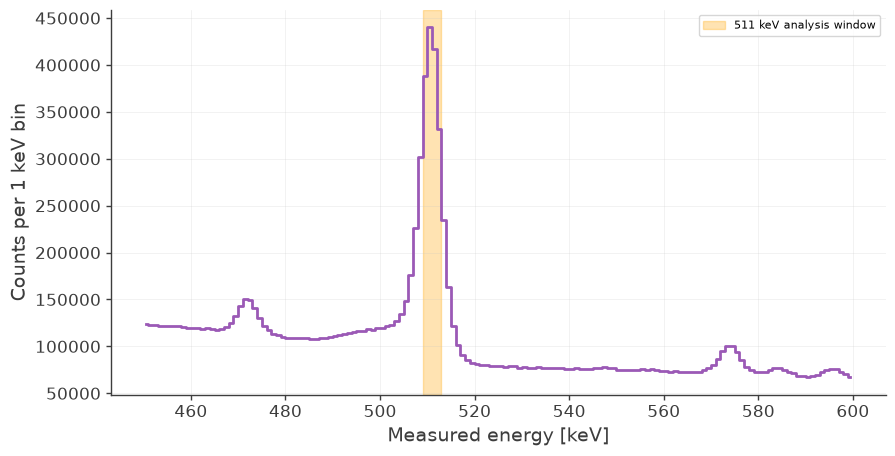

In [51]:
# Plot the combined energy spectrum
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers,
    energy_counts_all,
    where="mid",
)

# Highlight the 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)


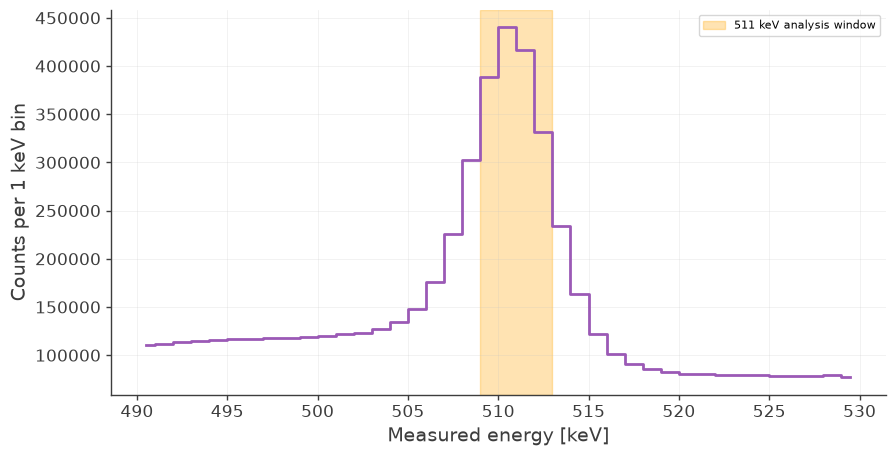

In [52]:
# Select the region around the 511 keV feature
zoom_mask = (
    (energy_bin_centers >= 490)
    & (energy_bin_centers <= 530)
)

# Plot a closer view of the 511 keV feature
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers[zoom_mask],
    energy_counts_all[zoom_mask],
    where="mid",
)

# Highlight the final 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Validation with simulated total background

***
## Fit Galactic disk and bulge model

In [21]:
# Using extended_response
# Select Ei=0 and Em=0
response_511 = extended_response[:, 0, 0, :, :]

In [22]:

print("511 keV response:", response_511.shape)
print("511 keV (reduced) response:", response_511.shape[1:])
print("Total observed shape:" , observed_counts_all.shape)

511 keV response: (3072, 60, 3072)
511 keV (reduced) response: (60, 3072)
Total observed shape: (60, 3072)
